In [11]:
import importlib
import numpy as np
import gsd.hoomd

from md_Helpers import (
    paths, spatial, metadata, lattices, simulation, runs,
    classification, cavitation, cavitation_analysis,
    visualization, index,
)

for module in [
    paths, spatial, metadata, lattices, classification, runs,
    simulation, cavitation, cavitation_analysis, visualization, index,
]:
    importlib.reload(module)

print("All V3 modules imported successfully.")

All V3 modules imported successfully.


Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_20/rho_0.800/kT_0.800/nsteps_100000/seed_1/randomization.gsd
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_20/rho_0.800/kT_0.800/nsteps_100000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_20/source_rho_0.800/kT_0.800/source_nsteps_100000/source_seed_1/source_phase_randomization/radius_fraction_0.100/center_box/cavitation_initial.gsd


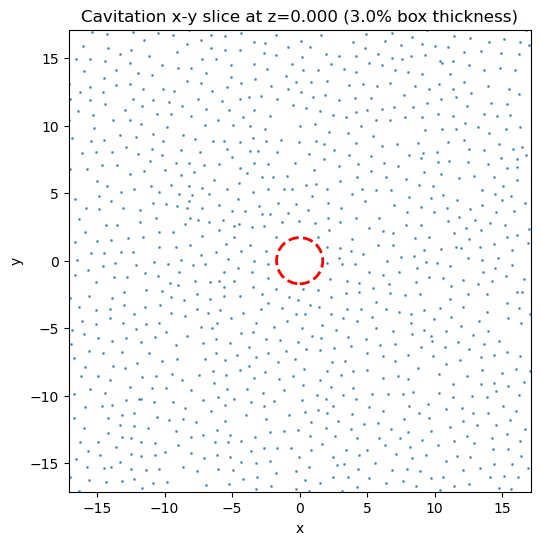

{'created_new': False,
 'state_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_20/source_rho_0.800/kT_0.800/source_nsteps_100000/source_seed_1/source_phase_randomization/radius_fraction_0.100/center_box/cavitation_initial.gsd',
 'creation_metadata_path': '/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_20/source_rho_0.800/kT_0.800/source_nsteps_100000/source_seed_1/source_phase_randomization/radius_fraction_0.100/center_box/cavitation_creation.hdf5',
 'N_after': 31982,
 'rho_after': 0.7995499174102353,
 'BoxLength': 34.199520111083984,
 'N_before': 32000,
 'bubble_center': array([0., 0., 0.]),
 'bubble_center_x': 0.0,
 'bubble_center_y': 0.0,
 'bubble_center_z': 0.0,
 'bubble_method': 'remove_particles_in_sphere',
 'bubble_radius': 1.7099760055541993,
 'bubble_seed': 1,
 'copied_particle_fields': 'position,typeid,velocity,mass,charge,diameter,body,image,orientation,moment_inertia',
 'particle_fraction_removed': 0.0005625,
 'particles_re

In [8]:
thermal = simulation.get_or_make_thermalized_state(
    n_fcc_cells=20,
    target_rho=0.800,
    kT=0.800,
    nsteps=100_000,
    overwrite=False,
)

initial = cavitation.get_or_create_cavitation_state(
    n_fcc_cells=20,
    target_rho=0.800,
    kT=0.800,
    source_nsteps=100_000,
    radius_fraction=0.100,
    overwrite=False,
)

assert initial["paths"]["state_path"].exists()
assert initial["paths"]["creation_metadata_path"].exists()
assert initial["creation_info"]["particles_removed"] > 0

visualization.plot_cavitation_xy_slice(initial, fraction=0.03)
initial["creation_info"]

In [12]:
evolution = cavitation.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius_fraction=0.15,
    evolve_nsteps=100_000,
)


with gsd.hoomd.open(evolution["paths"]["trajectory_path"], "r") as trajectory:
    trajectory_steps = [
        frame.configuration.step for frame in trajectory
    ]
    assert np.allclose(
        trajectory[0].particles.position,
        initial["frame"].particles.position,
    )

log = runs.read_hdf5_log(evolution["paths"]["log_path"])
log_steps = log["hoomd-data"]["Simulation"]["timestep"]

assert trajectory_steps[0] == log_steps[0]
print("Trajectory steps:", trajectory_steps)
print("Log steps:", log_steps)

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/cavitation_initial.gsd
Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_final.gsd


ValueError: operands could not be broadcast together with shapes (107823,3) (31982,3) 

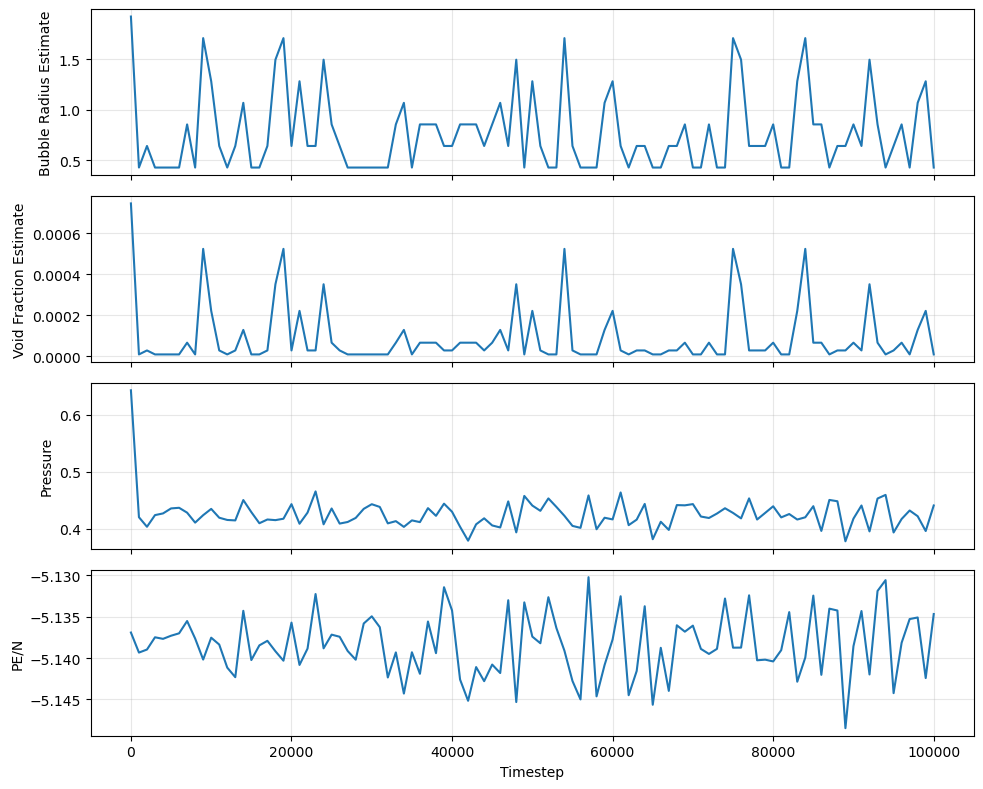

,frame_index,timestep,N,BoxLength_x,BoxLength_y,BoxLength_z,volume,bulk_density,bubble_center_x,bubble_center_y,...,void_fraction_estimate,initial_bubble_radius,particles_inside_initial_radius,density_inside_initial_radius,kinetic_temperature,pressure,potential_energy,kinetic_energy,PE_per_particle,KE_per_particle
0,0,0,31982,34.19952,34.19952,34.19952,40000.004132,0.79955,0.0,0.0,...,0.000746,1.709976,0,0.000000,0.803542,0.642452,-164288.845128,38547.115489,-5.136916,1.205275
1,1,1000,31982,34.19952,34.19952,34.19952,40000.004132,0.79955,0.0,0.0,...,0.000008,1.709976,20,0.954930,0.799774,0.419901,-164366.357558,38366.379177,-5.139340,1.199624
2,2,2000,31982,34.19952,34.19952,34.19952,40000.004132,0.79955,0.0,0.0,...,0.000028,1.709976,18,0.859437,0.802675,0.403146,-164354.608623,38505.519849,-5.138972,1.203975
3,3,3000,31982,34.19952,34.19952,34.19952,40000.004132,0.79955,0.0,0.0,...,0.000008,1.709976,13,0.620704,0.792768,0.423592,-164307.249556,38030.283788,-5.137491,1.189115
4,4,4000,31982,34.19952,34.19952,34.19952,40000.004132,0.79955,0.0,0.0,...,0.000008,1.709976,19,0.907183,0.803069,0.426562,-164313.318948,38524.446651,-5.137681,1.204567


Indexed rows: 522


,hdf5_path,paths.metadata_path,paths.old_state_path,paths.state_path,source.old_state_path,source.source_data_version,state.BoxLength,state.N,state.actual_rho,state.data_version,...,paths.final_state_path,paths.trajectory_path,run.includes_initial_frame,run.includes_initial_log_row,run.kT,run.trajectory_period,source.parent_log_path,source.parent_state_kind,source.parent_state_path,source.source_creation_metadata_path
0,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,v2,1.709976,4.0,0.8,v3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,v2,20.000000,4000.0,0.5,v3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,v2,25.649639,13500.0,0.8,v3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,v2,3.419952,32.0,0.8,v3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,v2,43.088696,32000.0,0.4,v3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [10]:
classification.classify_final_state(
    state_path=evolution["paths"]["final_state_path"],
    log_path=evolution["paths"]["log_path"],
)

measurements = cavitation_analysis.measure_cavitation_trajectory(
    evolution,
    save_csv_path=evolution["paths"]["folder"] / "cavitation_measurements.csv",
)

visualization.plot_cavitation_measurements(measurements)
display(measurements.head())

index_table = index.scan_v3_metadata()
print("Indexed rows:", len(index_table))
display(index_table.head())

# Requires pyarrow:
index.build_v3_index()

In [ ]:
from IPython.display import display
from md_Helpers import visualization

creation_info = evolution["initial_result"]["creation_info"]
center_z = creation_info.get(
    "bubble_center_z",
    creation_info.get("bubble_center", [0, 0, 0])[2],
)

display(
    visualization.animate_xy_slice_trajectory(
        evolution["paths"]["trajectory_path"],
        fraction=0.03,
        center_z=center_z,
        stride=1,
        max_frames=100,
        point_size=2,
        alpha=0.7,
        interval=120,
    )
)